# 01 · Data Exploration — Multi-Session Chat (MSC)

We study **memory importance** in long-term dialogue: given the utterances from previous sessions of a conversation (the *memory bank*), which ones will be *referenced again* later? The target `label_retain` is 1 when a memory is referenced or paraphrased in the following session.

**Challenges:** (1) no off-the-shelf relevance labels; (2) severe class imbalance — most memories are never re-referenced; (3) short, noisy utterances.

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings('ignore')
ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT / 'src'))
import pandas as pd, numpy as np, json
from IPython.display import Image, display
PROC, RES, FIG = ROOT/'data'/'processed', ROOT/'results', ROOT/'reports'/'figures'


## Parsed memory records

In [2]:
mems = pd.DataFrame(json.loads(l) for l in open(PROC/'memories.jsonl'))
eps = [json.loads(l) for l in open(PROC/'episodes.jsonl')]
print(f'{len(mems)} memories across {mems.episode_id.nunique()} episodes '
      f'from {len(eps)} episodes file')
mems[['episode_id','memory_session','recency_sessions','role_speaker1','text']].head(6)

17631 memories across 450 episodes from 450 episodes file


,episode_id,memory_session,recency_sessions,role_speaker1,text
0,s3_valid_0,1,2,1,Hello what are doing today?
1,s3_valid_0,1,2,0,"I am good, I just got off work and tired, I ha..."
2,s3_valid_0,1,2,1,I just got done watching a horror movie
3,s3_valid_0,1,2,0,"I rather read, I've read about 20 books this y..."
4,s3_valid_0,1,2,1,Wow! I do love a good horror movie. Loving thi...
5,s3_valid_0,1,2,0,But a good movie is always good.


## Memory-bank depth and recency

In [3]:
print('memories per episode:', round(len(mems)/mems.episode_id.nunique(),1))
mems.recency_sessions.value_counts().sort_index()

memories per episode: 39.2


recency_sessions
1    5324
2    5874
3    4107
4    2326
Name: count, dtype: int64

## Human persona-worthiness annotation (used for label validation)

MSC's `msc_personasummary` split annotates each utterance with the persona fact it contributes. We recovered this for every memory and use it as an *independent* human notion of importance.

In [4]:
mems['persona_worthy'] = mems['persona_worthy'].astype(bool)
print('persona-worthy rate:', round(mems.persona_worthy.mean(),3))
display(mems[mems.persona_worthy][['text','persona_text']].head(4))
display(mems[~mems.persona_worthy][['text']].head(4))

persona-worthy rate: 0.64


,text,persona_text
1,"I am good, I just got off work and tired, I ha...",I have two jobs.
2,I just got done watching a horror movie,I watch horror movies.
3,"I rather read, I've read about 20 books this y...",I've read 20 books this year. I like to read.
4,Wow! I do love a good horror movie. Loving thi...,I like cooler weather.


,text
0,Hello what are doing today?
12,I bet she appreciates that very much.
28,Hi! How are you doing tonight?
31,That's neat. What kind of volunteer work do yo...


## Label distribution & validation stats

In [5]:
stats = json.load(open(RES/'label_stats.json'))
print(json.dumps(stats, indent=2))

{
  "positive_rate": 0.15637229879190062,
  "n": 17631,
  "agreement_persona_worthy": 0.4401338551415121,
  "cohen_kappa": 0.06109980048729624,
  "p_retain_given_worthy": 0.1848307637781322,
  "p_retain_given_not_worthy": 0.10575256107171001,
  "odds_ratio": 1.9173141968509042,
  "chi2": 191.93069081400301,
  "chi2_pvalue": 1.204796951413385e-43,
  "trigger_counts": {
    "content": 1778,
    "named": 558,
    "paraphrase": 421
  },
  "tau_paraphrase": 0.6,
  "min_content_overlap": 2
}


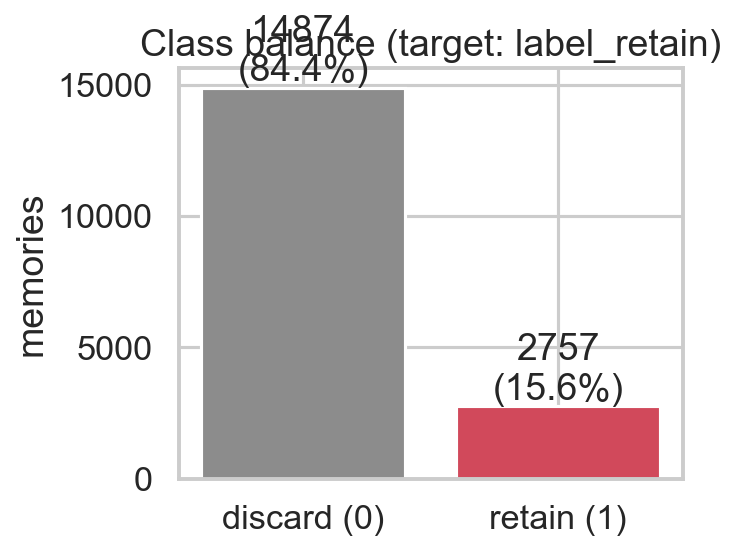

In [6]:
display(Image(str(FIG/'class_balance.png')))

**Takeaway.** The retain class is ~16% of memories (imbalanced). Our reference-based label is a statistically significant but distinct signal from human persona-worthiness (odds ratio ≈ 1.9), confirming it captures real 'will-be-used-again' structure rather than restating the annotation.